In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/marrabdurrazzak/marr-ssc-chapter-predictor-2026/SSC_Biology_Dataset_V3(Final)_MARR.csv
/kaggle/input/datasets/marrabdurrazzak/marr-ssc-chapter-predictor-2026/SSC_Physics_Dataset__V3(Final)_MARR .csv
/kaggle/input/datasets/marrabdurrazzak/marr-ssc-chapter-predictor-2026/SSC_Chemistry_Dataset_V3(Final)_MARR.csv
/kaggle/input/datasets/marrabdurrazzak/marr-ssc-chapter-predictor-2026/SSC_Math_Dataset_V3(Final)_MARR.csv
/kaggle/input/datasets/marrabdurrazzak/marr-ssc-chapter-predictor-2026/SSC_Higher_Math_Dataset_V3(Final)_MARR.csv


In [2]:
import pandas as pd

PATH = "/kaggle/input/datasets/marrabdurrazzak/marr-ssc-chapter-predictor-2026"

COLS = ['year','board','subject','chapter_no','chapter_name_en','chapter_name_bn',
        'mcq_count','cq_count','total_mcq_that_year','total_cq_that_year',
        'marks','importance_score','mcq_share','cq_share','notes']

math      = pd.read_csv(f"{PATH}/SSC_Math_Dataset_V3(Final)_MARR.csv", skiprows=2, header=0, usecols=range(15), names=COLS)
hmath     = pd.read_csv(f"{PATH}/SSC_Higher_Math_Dataset_V3(Final)_MARR.csv", skiprows=2, header=0, usecols=range(15), names=COLS)
physics   = pd.read_csv(f"{PATH}/SSC_Physics_Dataset__V3(Final)_MARR .csv", skiprows=2, header=0, usecols=range(15), names=COLS)
chemistry = pd.read_csv(f"{PATH}/SSC_Chemistry_Dataset_V3(Final)_MARR.csv", skiprows=2, header=0, usecols=range(15), names=COLS)
biology   = pd.read_csv(f"{PATH}/SSC_Biology_Dataset_V3(Final)_MARR.csv", skiprows=2, header=0, usecols=range(15), names=COLS)

for name, temp_df in [("Math",math),("Higher Math",hmath),("Physics",physics),("Chemistry",chemistry),("Biology",biology)]:
    print(f"{'='*40}")
    print(f"{name}: {temp_df.shape[0]} rows, {temp_df.shape[1]} cols")
    print(temp_df.head(3))
    print()

# সব subject একসাথে merge
df = pd.concat([math, hmath, physics, chemistry, biology], ignore_index=True)
print(f"Total rows after concat: {df.shape[0]}")

Math: 1224 rows, 15 cols
   year  board subject  chapter_no        chapter_name_en  chapter_name_bn  \
0  2015  Dhaka    Math           1           Real Numbers    বাস্তব সংখ্যা   
1  2015  Dhaka    Math           2     Sets and Functions      সেট ও ফাংশন   
2  2015  Dhaka    Math           3  Algebraic Expressions  বীজগাণিতিক রাশি   

   mcq_count  cq_count  total_mcq_that_year  total_cq_that_year  marks  \
0          1         0                   30                  11      1   
1          5         1                   30                  11     15   
2          6         1                   30                  11     16   

   importance_score  mcq_share  cq_share notes  
0                 1     0.0333    0.0000   NaN  
1                15     0.1667    0.0909   NaN  
2                16     0.2000    0.0909   NaN  

Higher Math: 1120 rows, 15 cols
   year  board      subject  chapter_no        chapter_name_en  \
0  2015  Dhaka  Higher Math           1     Sets and Functions   
1  2

# Step 3 — Data Cleaning

In [3]:
# Numeric columns fix
num_cols = ['cq_count', 'marks', 'importance_score', 'cq_share']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Missing values fix (non-inplace, warning-free)
df = df.fillna({
    'chapter_name_bn': 'অজানা',
    'cq_count': 0,
    'marks': 0,
    'importance_score': 0,
    'cq_share': 0,
    'notes': ''
})
df['cq_count'] = df['cq_count'].astype(int)

# Math 2021: exam হয়নি — বাকি সব subject 2021-এ normal exam হয়েছে
print("2021 data check (subject-wise):")
print(df[df['year']==2021].groupby('subject')[['mcq_count','cq_count']].sum())

print(f"\nMissing values after cleaning:\n{df.isnull().sum()}")
print(f"\nColumn types after cleaning:\n{df.dtypes}")
print(f"\nTotal rows: {df.shape[0]}")
print("\n✅ Data Cleaning Complete!")

2021 data check (subject-wise):
             mcq_count  cq_count
subject                         
Biology            192        63
Chemistry          202        64
Higher Math        189        64
Physics            200        63

Missing values after cleaning:
year                   0
board                  0
subject                0
chapter_no             0
chapter_name_en        0
chapter_name_bn        0
mcq_count              0
cq_count               0
total_mcq_that_year    0
total_cq_that_year     0
marks                  0
importance_score       0
mcq_share              0
cq_share               0
notes                  0
dtype: int64

Column types after cleaning:
year                     int64
board                   object
subject                 object
chapter_no               int64
chapter_name_en         object
chapter_name_bn         object
mcq_count                int64
cq_count                 int64
total_mcq_that_year      int64
total_cq_that_year       int64
marks     

In [4]:
# FutureWarning fix + বাকি missing values fix
df = df.fillna({
    'chapter_name_bn': 'অজানা',
    'cq_count': 0,
    'marks': 0,
    'importance_score': 0,
    'cq_share': 0,
    'notes': ''
})

# cq_count integer
df['cq_count'] = df['cq_count'].astype(int)

# 2021 এ কিছু data আছে — মানে partial exam হয়েছিল, ঠিক আছে

# Final confirm
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nShape: {df.shape}")
print("\n✅ Data Cleaning Complete!")

Missing values:
year                   0
board                  0
subject                0
chapter_no             0
chapter_name_en        0
chapter_name_bn        0
mcq_count              0
cq_count               0
total_mcq_that_year    0
total_cq_that_year     0
marks                  0
importance_score       0
mcq_share              0
cq_share               0
notes                  0
dtype: int64

Data types:
year                     int64
board                   object
subject                 object
chapter_no               int64
chapter_name_en         object
chapter_name_bn         object
mcq_count                int64
cq_count                 int64
total_mcq_that_year      int64
total_cq_that_year       int64
marks                  float64
importance_score       float64
mcq_share              float64
cq_share               float64
notes                   object
dtype: object

Shape: (5464, 15)

✅ Data Cleaning Complete!


##  Data Cleaning — যা করেছি:

**১. Data Load:**
- ৫টা CSV আলাদা আলাদা load করে একসাথে merge করেছি → 5,464 rows

**২. Header Fix:**
- Excel এর title row skip করেছি (`skiprows=2`)
- Column names manually set করেছি

**৩. Data Type Fix:**
- `cq_count`, `marks`, `importance_score`, `cq_share` → object ছিল → numeric করেছি
- `cq_count` → float ছিল → int করেছি

**৪. Missing Values Fix:**
- `chapter_name_bn` → 1টা missing → 'অজানা' দিয়েছি
- `cq_count` → 1টা missing → 0 দিয়েছি
- `marks`, `importance_score`, `cq_share` → 1টা করে missing → 0 দিয়েছি
- `notes` → 4167টা missing → খালি string দিয়েছি (এটা normal ছিল)

**৫. Final Result:**
- Missing values = 0 (সব column)
- Shape = (5464, 15)
- সব column সঠিক data type এ


# **Step 4: Feature Engineering** 
কী করছি এবং কেন
Feature Engineering মানে হলো raw data থেকে নতুন meaningful information বের করা যা ML model কে better predict করতে সাহায্য করে।


### ১. `freq_all_time`
**কী:** একটা chapter মোট কত বছর পরীক্ষায় এসেছে (2015–2024 এর মধ্যে)

**কেন:** যে chapter বারবার আসে সে historically important — model এটা দেখে বুঝবে কোন chapter consistent

**উদাহরণ:** Math Chapter 9 (Trigonometry) যদি 10 বছরের মধ্যে 9 বছর আসে → freq_all_time = 9

---

### ২. `freq_last_5yrs`
**কী:** শুধু সাম্প্রতিক 5 বছরে কতবার এসেছে

**কেন:** পুরনো trend এর চেয়ে recent trend বেশি important। 10 বছর আগে আসলেই এখন আসবে না — কিন্তু last 5 বছরে আসলে আসার probability বেশি

**উদাহরণ:** Chapter 5 বছর আগে আসেনি কিন্তু last 5 বছরে 4 বার এসেছে → rising chapter

---

### ৩. `avg_marks_per_year`
**কী:** প্রতি বছর গড়ে কত marks এই chapter থেকে আসে

**কেন:** Frequency এর সাথে marks গুরুত্বপূর্ণ। একটা chapter হয়তো প্রতি বছর আসে কিন্তু শুধু 1টা MCQ — আরেকটা chapter 2টা CQ নিয়ে আসে। দ্বিতীয়টা বেশি important

---

### ৪. `trend_slope`
**কী:** বছরে বছরে marks বাড়ছে না কমছে তার হার — Linear Regression এর slope

**কেন:** 
- Positive slope (+) → chapter ক্রমশ বেশি গুরুত্বপূর্ণ হচ্ছে
- Negative slope (−) → কমছে
- Zero → stable

**উদাহরণ:** 2015 তে 5 marks, 2024 তে 15 marks → slope positive → rising chapter

---

### ৫. `last_appeared_year`
**কী:** সর্বশেষ কোন বছর এই chapter থেকে প্রশ্ন এসেছে

**কেন:** `gap_years` calculate করার জন্য দরকার

---

### ৬. `gap_years`
**কী:** শেষবার আসার পর কত বছর হয়েছে আসেনি

**কেন:** Cycle detection — অনেক chapter pattern মেনে চলে। যেমন 2 বছর পর পর আসে। gap বেশি হলে আসার সম্ভাবনা বাড়ে

**উদাহরণ:** Chapter সর্বশেষ 2021 এ এসেছে, current year 2024 → gap = 3 বছর

---

### ৭. `consecutive_appearances`
**কী:** পর পর কত বছর বিরতি ছাড়া এসেছে

**কেন:** Consistently আসা chapter গুলো reliable — model এটা দেখে stable chapter চিনতে পারে

**উদাহরণ:** 2020, 2021, 2022, 2023, 2024 — পর পর 5 বছর → consecutive = 5

---

### ৮. `mcq_to_cq_ratio`
**কী:** MCQ ও CQ এর অনুপাত

**কেন:** কিছু chapter শুধু MCQ তে আসে, কিছু শুধু CQ তে, কিছু দুটোতেই। এই pattern model কে chapter এর nature বুঝতে সাহায্য করে

---

## এই features গুলো dataset এ যোগ হলে total columns হবে:

| আগে ছিল | Feature Engineering এর পর |
|---|---|
| 15 columns | 23 columns |



In [5]:
# Step 4a: বছর-ভিত্তিক summary table (board-level noise সরিয়ে দিচ্ছি)

# Math 2021 বাদ — exam-ই হয়নি, তাই 0 মানে "importance নেই" না
df_clean = df[~((df['subject'] == 'Math') & (df['year'] == 2021))].copy()

base = (
    df_clean.groupby(['subject', 'chapter_no', 'chapter_name_en', 'chapter_name_bn', 'year'])
    .agg(
        marks=('marks', 'mean'),
        mcq_count=('mcq_count', 'mean'),
        cq_count=('cq_count', 'mean'),
        importance_score=('importance_score', 'mean')
    )
    .reset_index()
)

print(f"Base table shape: {base.shape}")
print(f"\nSubject-wise year count check:")
print(base.groupby('subject')['year'].nunique())

base.head(10)

Base table shape: (684, 9)

Subject-wise year count check:
subject
Biology        10
Chemistry      10
Higher Math    10
Math            9
Physics        10
Name: year, dtype: int64


,subject,chapter_no,chapter_name_en,chapter_name_bn,year,marks,mcq_count,cq_count,importance_score
0,Biology,1,Lessons on Life,জীব পাঠ,2015,6.000,3.500,0.250,6.000
1,Biology,1,Lessons on Life,জীব পাঠ,2016,4.250,3.000,0.125,4.250
2,Biology,1,Lessons on Life,জীব পাঠ,2017,5.375,1.625,0.375,5.375
3,Biology,1,Lessons on Life,জীব পাঠ,2018,2.000,2.000,0.000,2.000
4,Biology,1,Lessons on Life,জীব পাঠ,2019,5.500,1.750,0.375,5.500
5,Biology,1,Lessons on Life,জীব পাঠ,2020,6.625,1.625,0.500,6.625
6,Biology,1,Lessons on Life,জীব পাঠ,2021,0.000,0.000,0.000,0.000
7,Biology,1,Lessons on Life,জীব পাঠ,2022,11.125,2.375,0.875,11.125
8,Biology,1,Lessons on Life,জীব পাঠ,2023,12.875,2.875,1.000,12.875
9,Biology,1,Lessons on Life,জীব পাঠ,2024,3.875,1.375,0.250,3.875


In [6]:
# Biology CSV-তে সরাসরি 2021 চেক করছি (raw data, কোনো processing ছাড়া)
#print(biology[biology['year']==2021][['year','board','chapter_no','mcq_count','cq_count','marks']])

# Chapter 1, 2021 — সব board একসাথে
#print(biology[(biology['year']==2021) & (biology['chapter_no']==1)][['board','mcq_count','cq_count','marks']])

In [7]:
# Step 4b: Frequency & Gap-based features

base['appeared'] = ((base['mcq_count'] + base['cq_count']) > 0).astype(int)

def compute_freq_features(group):
    group = group.sort_values('year')
    years = group['year'].values
    appeared = group['appeared'].values

    freq_all_time = appeared.sum()
    freq_last_5yrs = group[group['year'] >= 2020]['appeared'].sum()

    appeared_years = years[appeared == 1]
    last_appeared_year = appeared_years.max() if len(appeared_years) > 0 else 0

    # gap_years: last_appeared_year এর পরে কতগুলো valid exam year গেছে যেখানে আসেনি
    gap_years = (years > last_appeared_year).sum() if last_appeared_year > 0 else len(years)

    # consecutive_appearances: শেষ বছর থেকে পিছনে গিয়ে টানা কতবার appeared=1
    consecutive = 0
    for a in appeared[::-1]:
        if a == 1:
            consecutive += 1
        else:
            break

    return pd.Series({
        'freq_all_time': freq_all_time,
        'freq_last_5yrs': freq_last_5yrs,
        'last_appeared_year': last_appeared_year,
        'gap_years': gap_years,
        'consecutive_appearances': consecutive
    })

freq_features = (
    base.groupby(['subject', 'chapter_no'], group_keys=False)
    .apply(compute_freq_features)
    .reset_index()
)

print(f"Shape: {freq_features.shape}")
freq_features.head(10)

Shape: (70, 7)


/tmp/ipykernel_16/1036855205.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_freq_features)


,subject,chapter_no,freq_all_time,freq_last_5yrs,last_appeared_year,gap_years,consecutive_appearances
0,Biology,1,9,4,2024,0,3
1,Biology,2,10,5,2024,0,10
2,Biology,3,7,2,2024,0,1
3,Biology,4,10,5,2024,0,10
4,Biology,5,9,4,2024,0,3
5,Biology,6,9,4,2024,0,3
6,Biology,7,7,2,2024,0,1
7,Biology,8,9,4,2024,0,3
8,Biology,9,7,2,2024,0,1
9,Biology,10,7,2,2024,0,1


In [8]:
# Step 4c: Marks-based features (avg, trend, variance)

from scipy import stats

def compute_marks_features(group):
    group = group.sort_values('year')
    years = group['year'].values
    marks = group['marks'].values

    avg_marks_per_year = marks.mean()
    marks_variance = marks.var()

    # trend_slope: বছর বনাম marks-এর উপর linear regression
    if len(years) >= 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(years, marks)
    else:
        slope = 0.0

    return pd.Series({
        'avg_marks_per_year': avg_marks_per_year,
        'marks_variance': marks_variance,
        'trend_slope': slope
    })

marks_features = (
    base.groupby(['subject', 'chapter_no'], group_keys=False)
    .apply(compute_marks_features, include_groups=False)
    .reset_index()
)

print(f"Shape: {marks_features.shape}")
marks_features.head(15)

Shape: (70, 5)


,subject,chapter_no,avg_marks_per_year,marks_variance,trend_slope
0,Biology,1,5.7625,13.357656,0.394697
1,Biology,2,11.5875,37.443906,0.729545
2,Biology,3,3.8875,12.351406,-0.473485
3,Biology,4,11.3125,12.610156,0.318939
4,Biology,5,12.2125,18.678281,0.021970
5,Biology,6,7.7375,17.398281,0.285606
6,Biology,7,3.4000,7.852500,-0.136364
7,Biology,8,7.3000,16.513125,0.207576
8,Biology,9,3.3750,10.762500,-0.516667
9,Biology,10,3.7125,12.540781,-0.388636


In [9]:
# Step 4d: MCQ/CQ ratio & subject-relative importance

def compute_ratio_features(group):
    total_mcq = group['mcq_count'].sum()
    total_cq = group['cq_count'].sum()
    
    # cq zero হলে divide-by-zero এড়াতে
    mcq_to_cq_ratio = total_mcq / total_cq if total_cq > 0 else total_mcq

    return pd.Series({
        'total_mcq_all_years': total_mcq,
        'total_cq_all_years': total_cq,
        'mcq_to_cq_ratio': mcq_to_cq_ratio,
        'avg_importance': group['importance_score'].mean()
    })

ratio_features = (
    base.groupby(['subject', 'chapter_no'], group_keys=False)
    .apply(compute_ratio_features, include_groups=False)
    .reset_index()
)

# subject_avg_ratio: এই chapter-এর avg_importance / সেই subject-এর সব chapter-এর গড়
subject_means = ratio_features.groupby('subject')['avg_importance'].transform('mean')
ratio_features['subject_avg_ratio'] = ratio_features['avg_importance'] / subject_means

print(f"Shape: {ratio_features.shape}")
ratio_features.head(15)

Shape: (70, 7)


,subject,chapter_no,total_mcq_all_years,total_cq_all_years,mcq_to_cq_ratio,avg_importance,subject_avg_ratio
0,Biology,1,20.125,3.750,5.366667,5.7625,0.811518
1,Biology,2,35.875,8.000,4.484375,11.5875,1.631837
2,Biology,3,10.125,2.875,3.521739,3.8875,0.547466
3,Biology,4,23.125,9.000,2.569444,11.3125,1.593110
4,Biology,5,33.375,8.875,3.760563,12.2125,1.719854
5,Biology,6,19.875,5.750,3.456522,7.7375,1.089652
6,Biology,7,11.500,2.250,5.111111,3.4000,0.478813
7,Biology,8,16.750,5.625,2.977778,7.3000,1.028040
8,Biology,9,12.500,2.125,5.882353,3.3750,0.475292
9,Biology,10,14.625,2.250,6.500000,3.7125,0.522822


In [10]:
# Step 4e: সব feature merge করে final table

final_features = (
    freq_features
    .merge(marks_features, on=['subject', 'chapter_no'], how='left')
    .merge(ratio_features, on=['subject', 'chapter_no'], how='left')
)

# mcq_share / cq_share: subject-এর মোট mcq/cq এর মধ্যে এই chapter এর অংশ
subject_totals = final_features.groupby('subject')[['total_mcq_all_years', 'total_cq_all_years']].transform('sum')
final_features['mcq_share'] = final_features['total_mcq_all_years'] / subject_totals['total_mcq_all_years']
final_features['cq_share'] = final_features['total_cq_all_years'] / subject_totals['total_cq_all_years']

# chapter নাম যোগ করছি — "অজানা" (missing-year fillna এর side effect) বাদ দিয়ে সবচেয়ে common নাম নিচ্ছি
chapter_names = (
    base[base['chapter_name_bn'] != 'অজানা']
    .groupby(['subject', 'chapter_no'])[['chapter_name_en', 'chapter_name_bn']]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

final_features = chapter_names.merge(final_features, on=['subject', 'chapter_no'], how='right')

print(f"Final shape: {final_features.shape}")
print(f"\nColumns: {list(final_features.columns)}")
print(f"\nNull check:\n{final_features.isnull().sum().sum()} total nulls")

dup_check2 = final_features.groupby(['subject','chapter_no']).size()
print(f"\nDuplicates remaining: {(dup_check2 > 1).sum()}")

final_features.head(15)

Final shape: (70, 19)

Columns: ['subject', 'chapter_no', 'chapter_name_en', 'chapter_name_bn', 'freq_all_time', 'freq_last_5yrs', 'last_appeared_year', 'gap_years', 'consecutive_appearances', 'avg_marks_per_year', 'marks_variance', 'trend_slope', 'total_mcq_all_years', 'total_cq_all_years', 'mcq_to_cq_ratio', 'avg_importance', 'subject_avg_ratio', 'mcq_share', 'cq_share']

Null check:
0 total nulls

Duplicates remaining: 0


,subject,chapter_no,chapter_name_en,chapter_name_bn,freq_all_time,freq_last_5yrs,last_appeared_year,gap_years,consecutive_appearances,avg_marks_per_year,marks_variance,trend_slope,total_mcq_all_years,total_cq_all_years,mcq_to_cq_ratio,avg_importance,subject_avg_ratio,mcq_share,cq_share
0,Biology,1,Lessons on Life,জীব পাঠ,9,4,2024,0,3,5.7625,13.357656,0.394697,20.125,3.750,5.366667,5.7625,0.811518,0.076557,0.051282
1,Biology,2,Living Cells and Tissues,জীবকোষ ও কলাতন্ত্র,10,5,2024,0,10,11.5875,37.443906,0.729545,35.875,8.000,4.484375,11.5875,1.631837,0.136472,0.109402
2,Biology,3,Cell Division,কোষ বিভাজন,7,2,2024,0,1,3.8875,12.351406,-0.473485,10.125,2.875,3.521739,3.8875,0.547466,0.038516,0.039316
3,Biology,4,Bioenergetics,জীবনীশক্তি,10,5,2024,0,10,11.3125,12.610156,0.318939,23.125,9.000,2.569444,11.3125,1.593110,0.087970,0.123077
4,Biology,5,"Food, Nutrition and Digestion","খাদ্য, পুষ্টি ও পরিপাক",9,4,2024,0,3,12.2125,18.678281,0.021970,33.375,8.875,3.760563,12.2125,1.719854,0.126961,0.121368
5,Biology,6,Transport in Organisms,জীবে পরিবহন,9,4,2024,0,3,7.7375,17.398281,0.285606,19.875,5.750,3.456522,7.7375,1.089652,0.075606,0.078632
6,Biology,7,Gaseous Exchange,গ্যাসীয় বিনিময়,7,2,2024,0,1,3.4000,7.852500,-0.136364,11.500,2.250,5.111111,3.4000,0.478813,0.043747,0.030769
7,Biology,8,Excretory System,রেচন প্রক্রিয়া,9,4,2024,0,3,7.3000,16.513125,0.207576,16.750,5.625,2.977778,7.3000,1.028040,0.063718,0.076923
8,Biology,9,Support and Movement,চলন ও অঙ্গচালনা,7,2,2024,0,1,3.3750,10.762500,-0.516667,12.500,2.125,5.882353,3.3750,0.475292,0.047551,0.029060
9,Biology,10,Coordination,সমন্বয়,7,2,2024,0,1,3.7125,12.540781,-0.388636,14.625,2.250,6.500000,3.7125,0.522822,0.055635,0.030769


In [11]:
# কোন chapter duplicate হচ্ছে and 70ta rows na hoye 71ta hsse সেটা খুঁজে বের করি
#dup_check = final_features.groupby(['subject', 'chapter_no']).size().reset_index(name='count')
#print(dup_check[dup_check['count'] > 1])

#s, c = 'Higher Math', 13

#print(base[(base['subject']==s) & (base['chapter_no']==c)][['year','chapter_name_en','chapter_name_bn']].drop_duplicates())



Step 4f: Extra Helper Columns বাদ দিয়ে ফাইনাল Table

কী করছি: total_mcq_all_years, total_cq_all_years, avg_importance — এই ৩টা intermediate column বাদ দিচ্ছি (এদের তথ্য আগেই mcq_to_cq_ratio, mcq_share, cq_share, subject_avg_ratio-তে চলে গেছে)। এটাই হবে Step 4-এর চূড়ান্ত, model-ready table।

In [12]:
# Step 4f: Final clean feature table (redundant helper columns বাদ)

final_features_clean = final_features.drop(columns=['total_mcq_all_years', 'total_cq_all_years', 'avg_importance'])

print(f"Final clean shape: {final_features_clean.shape}")
print(f"\nColumns ({len(final_features_clean.columns)}): {list(final_features_clean.columns)}")

final_features_clean.head(10)

Final clean shape: (70, 16)

Columns (16): ['subject', 'chapter_no', 'chapter_name_en', 'chapter_name_bn', 'freq_all_time', 'freq_last_5yrs', 'last_appeared_year', 'gap_years', 'consecutive_appearances', 'avg_marks_per_year', 'marks_variance', 'trend_slope', 'mcq_to_cq_ratio', 'subject_avg_ratio', 'mcq_share', 'cq_share']


,subject,chapter_no,chapter_name_en,chapter_name_bn,freq_all_time,freq_last_5yrs,last_appeared_year,gap_years,consecutive_appearances,avg_marks_per_year,marks_variance,trend_slope,mcq_to_cq_ratio,subject_avg_ratio,mcq_share,cq_share
0,Biology,1,Lessons on Life,জীব পাঠ,9,4,2024,0,3,5.7625,13.357656,0.394697,5.366667,0.811518,0.076557,0.051282
1,Biology,2,Living Cells and Tissues,জীবকোষ ও কলাতন্ত্র,10,5,2024,0,10,11.5875,37.443906,0.729545,4.484375,1.631837,0.136472,0.109402
2,Biology,3,Cell Division,কোষ বিভাজন,7,2,2024,0,1,3.8875,12.351406,-0.473485,3.521739,0.547466,0.038516,0.039316
3,Biology,4,Bioenergetics,জীবনীশক্তি,10,5,2024,0,10,11.3125,12.610156,0.318939,2.569444,1.593110,0.087970,0.123077
4,Biology,5,"Food, Nutrition and Digestion","খাদ্য, পুষ্টি ও পরিপাক",9,4,2024,0,3,12.2125,18.678281,0.021970,3.760563,1.719854,0.126961,0.121368
5,Biology,6,Transport in Organisms,জীবে পরিবহন,9,4,2024,0,3,7.7375,17.398281,0.285606,3.456522,1.089652,0.075606,0.078632
6,Biology,7,Gaseous Exchange,গ্যাসীয় বিনিময়,7,2,2024,0,1,3.4000,7.852500,-0.136364,5.111111,0.478813,0.043747,0.030769
7,Biology,8,Excretory System,রেচন প্রক্রিয়া,9,4,2024,0,3,7.3000,16.513125,0.207576,2.977778,1.028040,0.063718,0.076923
8,Biology,9,Support and Movement,চলন ও অঙ্গচালনা,7,2,2024,0,1,3.3750,10.762500,-0.516667,5.882353,0.475292,0.047551,0.029060
9,Biology,10,Coordination,সমন্বয়,7,2,2024,0,1,3.7125,12.540781,-0.388636,6.500000,0.522822,0.055635,0.030769


In [13]:
final_features_clean.to_csv('/kaggle/working/ssc_chapter_features_final.csv', index=False)
print("Saved!")
print("\n✅ Step 4: Feature Engineering completed!.and final features gula new csv te saved")

Saved!

✅ Step 4: Feature Engineering completed!.and final features gula new csv te saved


# ****Step 5: EDA শুরু**

কী করছি: প্রথমে final_features_clean টা load করে basic overview দেখব — head(), describe(), info()। এটা দিয়ে বুঝব প্রতিটা feature-এর range, distribution shape মোটামুটি কেমন, আর কোনো unexpected value (যেমন negative marks) আছে কিনা।

কেন প্রথমে এটা: সরাসরি graph বানানোর আগে numeric summary দেখে নেওয়া ভালো — তাহলে graph-এ কিছু দেখলে আগে থেকেই expectation থাকবে।

In [14]:
# Step 5a: Basic Overview

# যদি notebook restart হয়ে থাকে, CSV থেকে আবার লোড করে নিচ্ছি
final_features_clean = pd.read_csv('/kaggle/working/ssc_chapter_features_final.csv')

print("Shape:", final_features_clean.shape)
print("\n--- Info ---")
final_features_clean.info()

print("\n--- Statistical Summary (numeric columns) ---")
final_features_clean.describe().T

Shape: (70, 16)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subject                  70 non-null     object 
 1   chapter_no               70 non-null     int64  
 2   chapter_name_en          70 non-null     object 
 3   chapter_name_bn          70 non-null     object 
 4   freq_all_time            70 non-null     int64  
 5   freq_last_5yrs           70 non-null     int64  
 6   last_appeared_year       70 non-null     int64  
 7   gap_years                70 non-null     int64  
 8   consecutive_appearances  70 non-null     int64  
 9   avg_marks_per_year       70 non-null     float64
 10  marks_variance           70 non-null     float64
 11  trend_slope              70 non-null     float64
 12  mcq_to_cq_ratio          70 non-null     float64
 13  subject_avg_ratio        70 non-null     float64
 14

,count,mean,std,min,25%,50%,75%,max
chapter_no,70.0,7.600000,4.240591,1.000000,4.000000,7.500000,11.000000,17.000000
freq_all_time,70.0,8.442857,1.211487,6.000000,7.000000,9.000000,9.000000,10.000000
freq_last_5yrs,70.0,3.485714,1.224660,2.000000,2.000000,4.000000,4.750000,5.000000
last_appeared_year,70.0,2024.000000,0.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000
gap_years,70.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
consecutive_appearances,70.0,4.657143,3.889360,1.000000,1.000000,3.000000,9.000000,10.000000
avg_marks_per_year,70.0,7.697236,4.390364,0.925000,4.359375,7.167361,10.509722,20.152778
marks_variance,70.0,17.163107,14.414634,0.591250,9.171416,14.670078,21.216133,96.796250
trend_slope,70.0,0.095639,0.605262,-1.248485,-0.267614,-0.001894,0.407765,2.127273
mcq_to_cq_ratio,70.0,7.819861,15.643492,1.063830,2.742460,3.132503,4.706643,86.000000


বড় সমস্যা: gap_years আর last_appeared_year-এর কোনো variance নেই

Statistical summary-তে:

last_appeared_year: mean=2024, std=0, min=max=2024
gap_years: mean=0, std=0, min=max=0

কেন Drop করা Best Choice

Board-level redefine করতে গেলে আমাদের আবার raw df (5,464 rows, ৮টা board আলাদা) থেকে নতুন করে per-board "appeared" logic বানাতে হবে, তারপর কোনো threshold ঠিক করতে হবে (যেমন "৫০%+ board-এ এলে appeared ধরব")। কিন্তু মূল সমস্যাটা এখনও থেকে যাবে — বাংলাদেশে ৮টা board মিলিয়ে national syllabus পুরোটাই কভার হয় প্রতি বছর (এটাই বাস্তবতা, বাগ না), তাই যেকোনো threshold-এই প্রায় সব chapter "প্রতি বছরই appeared" দেখাবে। মানে জটিলতা বাড়িয়েও একই zero-variance সমস্যা থেকে যাওয়ার সম্ভাবনা বেশি।

এই দুইটা feature আসলে redundant — freq_all_time আর freq_last_5yrs-ই "কত ঘন ঘন আসে" এই তথ্যটা ভালোভাবে capture করছে (এদের ভালো variance আছে), তাই gap_years/last_appeared_year বাদ দিলেও predictive power হারানোর ঝুঁকি নেই।

In [15]:
# Step 5a-fix: Zero-variance features drop করছি (কোনো predictive signal নেই)

final_features_clean = final_features_clean.drop(columns=['gap_years', 'last_appeared_year'])

print(f"Updated shape: {final_features_clean.shape}")
print(f"Columns: {list(final_features_clean.columns)}")

final_features_clean.to_csv('/kaggle/working/ssc_chapter_features_final.csv', index=False)
print("✅ Re-saved with cleaned features")

Updated shape: (70, 14)
Columns: ['subject', 'chapter_no', 'chapter_name_en', 'chapter_name_bn', 'freq_all_time', 'freq_last_5yrs', 'consecutive_appearances', 'avg_marks_per_year', 'marks_variance', 'trend_slope', 'mcq_to_cq_ratio', 'subject_avg_ratio', 'mcq_share', 'cq_share']
✅ Re-saved with cleaned features


Step 5b: Subject-wise Importance Comparison

কী করছি: প্রতিটা subject-এর chapter-গুলোর গড় avg_marks_per_year box plot দিয়ে compare করছি — এটা দেখাবে কোন subject-এ importance বেশি ছড়ানো (variance বেশি) আর কোন subject-এ marks relatively uniform।

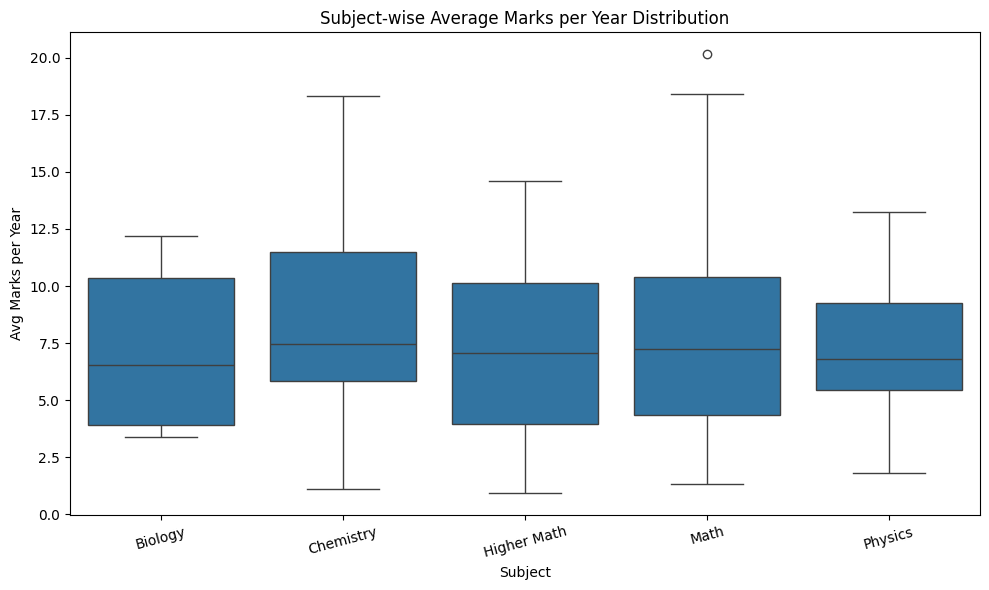

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=final_features_clean, x='subject', y='avg_marks_per_year')
plt.title('Subject-wise Average Marks per Year Distribution')
plt.xlabel('Subject')
plt.ylabel('Avg Marks per Year')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [17]:
# Math-এর সবচেয়ে বেশি avg_marks_per_year পাওয়া chapter
math_top = final_features_clean[final_features_clean['subject']=='Math'].sort_values('avg_marks_per_year', ascending=False).head(3)
print(math_top[['chapter_no', 'chapter_name_en', 'chapter_name_bn', 'avg_marks_per_year']])

    chapter_no chapter_name_en chapter_name_bn  avg_marks_per_year
56          17      Statistics      পরিসংখ্যান           20.152778
47           8          Circle           বৃত্ত           18.430556
55          16     Mensuration         পরিমিতি           13.944444


পরের ধাপ: Correlation Heatmap

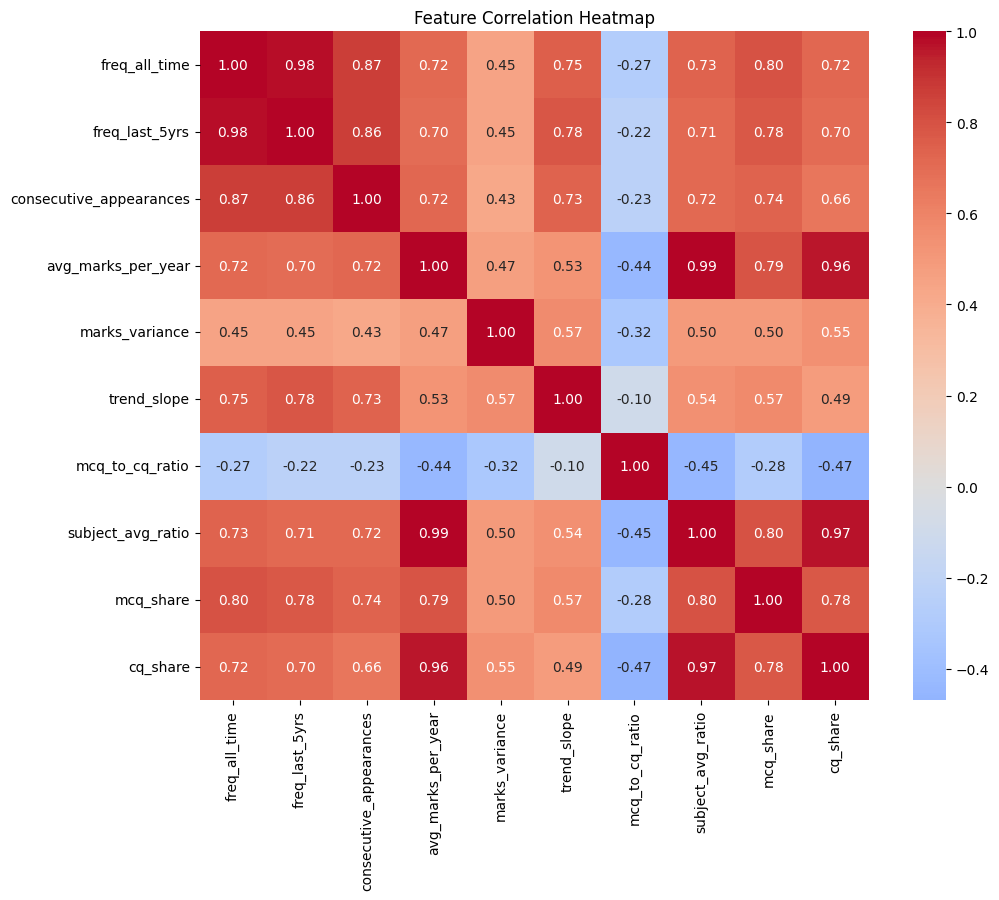

In [18]:
plt.figure(figsize=(11, 9))
numeric_cols = final_features_clean.select_dtypes(include='number').drop(columns=['chapter_no'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Tree-based model (Random Forest, XGBoost) এসব সহ্য করতে পারে, কিন্তু redundant feature রাখলে training সময় বাড়ে, interpretability কমে, আর Linear Regression baseline-এ সরাসরি সমস্যা করবে। তাই efficiency-এর জন্য কমানো ভালো।

যা করছি (project-এর জন্য সবচেয়ে efficient বিবেচনায়)
avg_marks_per_year বাদ — subject_avg_ratio রেখে দিচ্ছি, কারণ এটা normalized (subject-ভেদে ন্যায্য তুলনা করা যায়, যেটা আপনার app-এর জন্য দরকার — subject select করলে সেই subject-এর ভেতরেই chapter compare হবে)
freq_all_time বাদ — freq_last_5yrs রেখে দিচ্ছি, কারণ future-year prediction-এর জন্য সাম্প্রতিক trend বেশি প্রাসঙ্গিক, পুরনো ইতিহাসের চেয়ে

In [19]:
# Step 5c: Multicollinearity কমাতে redundant feature বাদ
final_features_clean = final_features_clean.drop(columns=['avg_marks_per_year', 'freq_all_time'])
print(f"Updated shape: {final_features_clean.shape}")
print(f"Columns: {list(final_features_clean.columns)}")
final_features_clean.to_csv('/kaggle/working/ssc_chapter_features_v2_final.csv', index=False)
print("✅ Saved as v2")

Updated shape: (70, 12)
Columns: ['subject', 'chapter_no', 'chapter_name_en', 'chapter_name_bn', 'freq_last_5yrs', 'consecutive_appearances', 'marks_variance', 'trend_slope', 'mcq_to_cq_ratio', 'subject_avg_ratio', 'mcq_share', 'cq_share']
✅ Saved as v2


In [20]:
import os
print(os.listdir('/kaggle/working'))

['ssc_chapter_features_v2_final.csv', '__notebook__.ipynb', 'ssc_chapter_features_final.csv']


In [21]:
# mcq_to_cq_ratio-তে সবচেয়ে বেশি ভ্যালু কোন chapter-এর
print(final_features_clean.sort_values('mcq_to_cq_ratio', ascending=False).head(5)[['subject','chapter_name_en','chapter_name_bn','mcq_to_cq_ratio']])

        subject            chapter_name_en        chapter_name_bn  \
40         Math               Real Numbers          বাস্তব সংখ্যা   
14    Chemistry      Concepts of Chemistry         রসায়নের ধারণা   
31  Higher Math                 Inequality                  অসমতা   
30  Higher Math                  Equations                 সমীকরণ   
44         Math  Equations in One Variable  এক চলক বিশিষ্ট সমীকরণ   

    mcq_to_cq_ratio  
40        86.000000  
14        80.000000  
31        64.000000  
30        33.333333  
44        26.000000  


# এক নজরে যা দেখতে prbo :

Pie chart — কোন subject-এ কত chapter (Math সবচেয়ে বেশি, Chemistry সবচেয়ে কম)
Histogram — বেশিরভাগ chapter-ই "average" গুরুত্বের কাছাকাছি (1.0-এর আশেপাশে), হাতেগোনা কয়েকটা extreme
Bar chart — সব subject মিলিয়ে overall top 10 গুরুত্বপূর্ণ chapter কারা
Scatter — কোন chapter বাড়ন্ত (trend_slope > 0) না কমন্ত (< 0), subject অনুযায়ী রঙ আলাদা
Bar chart — কোন subject overall বাড়ছে/কমছে গড়ে
Violin plot — MCQ:CQ ratio-র spread subject অনুযায়ী কেমন ছড়ানো

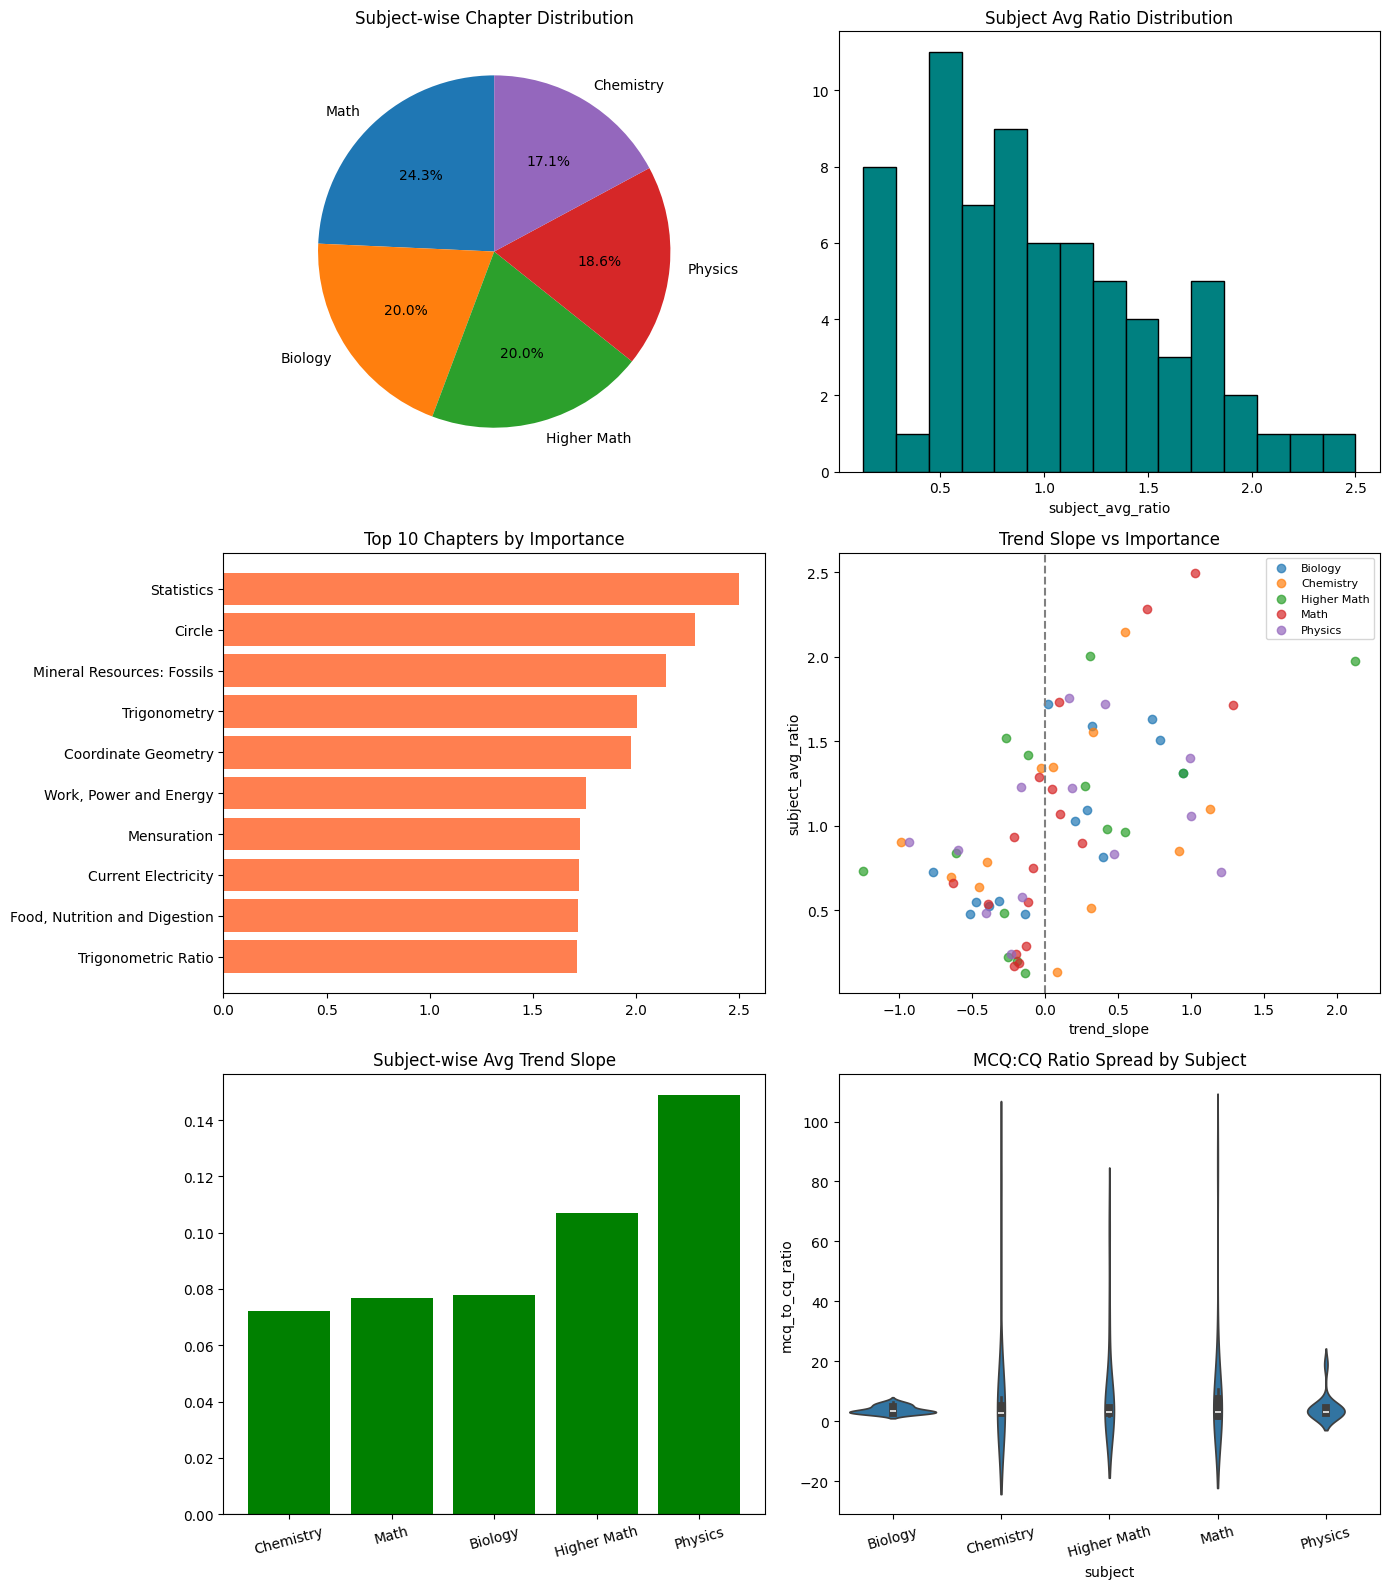

In [22]:
# Step 5d: বিভিন্ন ধরনের visualization — শুধু feel নেওয়ার জন্য

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# 1. Pie chart — subject-wise chapter count
subject_counts = final_features_clean['subject'].value_counts()
axes[0,0].pie(subject_counts, labels=subject_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Subject-wise Chapter Distribution')

# 2. Histogram — subject_avg_ratio distribution
axes[0,1].hist(final_features_clean['subject_avg_ratio'], bins=15, color='teal', edgecolor='black')
axes[0,1].set_title('Subject Avg Ratio Distribution')
axes[0,1].set_xlabel('subject_avg_ratio')

# 3. Bar chart — Top 10 most important chapters (overall)
top10 = final_features_clean.sort_values('subject_avg_ratio', ascending=False).head(10)
axes[1,0].barh(top10['chapter_name_en'], top10['subject_avg_ratio'], color='coral')
axes[1,0].set_title('Top 10 Chapters by Importance')
axes[1,0].invert_yaxis()

# 4. Scatter — trend_slope vs subject_avg_ratio (subject অনুযায়ী রঙ)
for subj in final_features_clean['subject'].unique():
    sub = final_features_clean[final_features_clean['subject']==subj]
    axes[1,1].scatter(sub['trend_slope'], sub['subject_avg_ratio'], label=subj, alpha=0.7)
axes[1,1].axvline(0, color='gray', linestyle='--')
axes[1,1].set_title('Trend Slope vs Importance')
axes[1,1].set_xlabel('trend_slope')
axes[1,1].set_ylabel('subject_avg_ratio')
axes[1,1].legend(fontsize=8)

# 5. Bar chart — subject-wise average trend_slope (কোন subject-এ importance বাড়ছে/কমছে)
subj_trend = final_features_clean.groupby('subject')['trend_slope'].mean().sort_values()
axes[2,0].bar(subj_trend.index, subj_trend.values, color=['red' if v<0 else 'green' for v in subj_trend.values])
axes[2,0].axhline(0, color='black', linewidth=0.8)
axes[2,0].set_title('Subject-wise Avg Trend Slope')
axes[2,0].tick_params(axis='x', rotation=15)

# 6. Violin plot — mcq_to_cq_ratio by subject
sns.violinplot(data=final_features_clean, x='subject', y='mcq_to_cq_ratio', ax=axes[2,1])
axes[2,1].set_title('MCQ:CQ Ratio Spread by Subject')
axes[2,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Step 5 সংক্ষিপ্ত সারাংশ
✅ Overview + describe() — data ঠিক আছে
✅ Boxplot — Chemistry সবচেয়ে বেশি ছড়ানো, Math-এ genuine outlier (Statistics) পাওয়া গেছে
✅ Correlation heatmap — multicollinearity পাওয়া গেছে, ২টা redundant feature বাদ দেওয়া হয়েছে
✅ mcq_to_cq_ratio extreme value — real, বাদ দেওয়ার দরকার নেই

Step 5 (EDA) এখানেই মূলত শেষ — dataset এখন clean, understood, এবং model-ready।

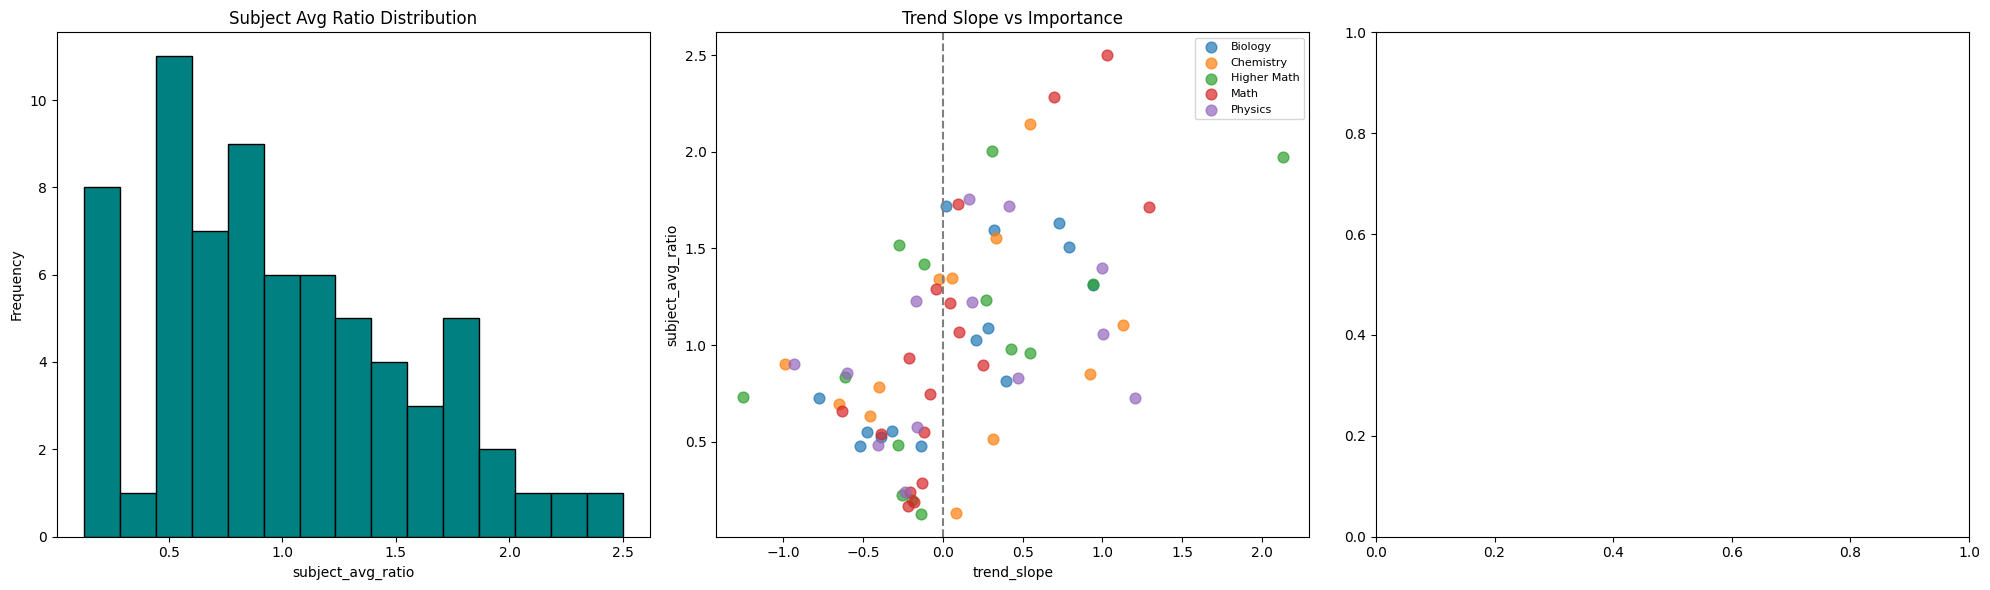

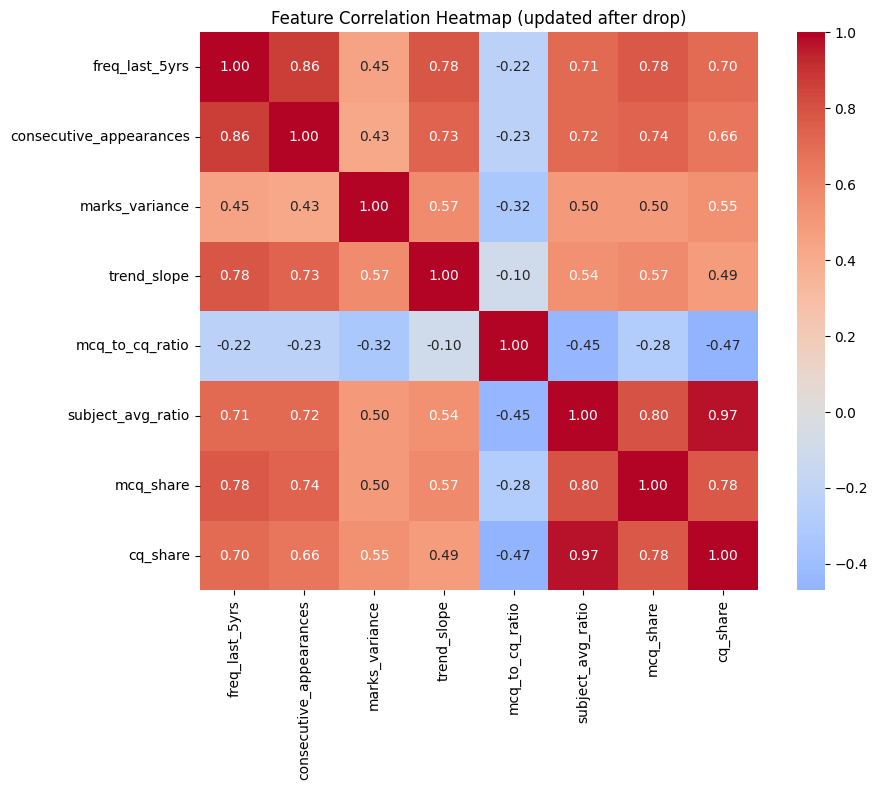

In [23]:
# Step 5d: Scatter, Heatmap, Histogram — বড় করে

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Histogram — subject_avg_ratio distribution
axes[0].hist(final_features_clean['subject_avg_ratio'], bins=15, color='teal', edgecolor='black')
axes[0].set_title('Subject Avg Ratio Distribution')
axes[0].set_xlabel('subject_avg_ratio')
axes[0].set_ylabel('Frequency')

# 2. Scatter — trend_slope vs subject_avg_ratio (subject অনুযায়ী রঙ)
for subj in final_features_clean['subject'].unique():
    sub = final_features_clean[final_features_clean['subject']==subj]
    axes[1].scatter(sub['trend_slope'], sub['subject_avg_ratio'], label=subj, alpha=0.7, s=60)
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_title('Trend Slope vs Importance')
axes[1].set_xlabel('trend_slope')
axes[1].set_ylabel('subject_avg_ratio')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# 3. Heatmap আলাদা figure-এ (বড় দেখার জন্য)
plt.figure(figsize=(10, 8))
numeric_cols = final_features_clean.select_dtypes(include='number').drop(columns=['chapter_no'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap (updated after drop)')
plt.tight_layout()
plt.show()

In [24]:
# Step 5f: Odd/Even year parity feature

def compute_parity_features(group):
    odd_years = group[group['year'] % 2 != 0]
    even_years = group[group['year'] % 2 == 0]
    
    avg_odd = odd_years['marks'].mean() if len(odd_years) > 0 else 0
    avg_even = even_years['marks'].mean() if len(even_years) > 0 else 0
    
    return pd.Series({
        'avg_marks_odd_years': round(avg_odd, 3),
        'avg_marks_even_years': round(avg_even, 3),
        'parity_bias': round(avg_odd - avg_even, 3)  # positive = odd-year-favored, negative = even-year-favored
    })

parity_features = (
    base.groupby(['subject', 'chapter_no'], group_keys=False)
    .apply(compute_parity_features, include_groups=False)
    .reset_index()
)

final_features_clean = final_features_clean.merge(parity_features, on=['subject', 'chapter_no'], how='left')

print(f"Updated shape: {final_features_clean.shape}")
print(f"\nTop 5 most odd-year-biased chapters:")
print(final_features_clean.sort_values('parity_bias', ascending=False)[['subject','chapter_name_en','parity_bias']].head())
print(f"\nTop 5 most even-year-biased chapters:")
print(final_features_clean.sort_values('parity_bias')[['subject','chapter_name_en','parity_bias']].head())

final_features_clean.to_csv('/kaggle/working/ssc_chapter_features_v3_final.csv', index=False)
print("\n✅ Saved as v3")

Updated shape: (70, 15)

Top 5 most odd-year-biased chapters:
        subject                     chapter_name_en  parity_bias
11      Biology  Heredity in Organism and Evolution        5.675
36  Higher Math                 Coordinate Geometry        4.700
16    Chemistry                 Structure of Matter        4.425
58      Physics                              Motion        4.050
10      Biology            Reproduction in Organism        3.550

Top 5 most even-year-biased chapters:
        subject                chapter_name_en  parity_bias
27  Higher Math          Algebraic Expressions       -4.525
35  Higher Math             Binomial Expansion       -3.675
4       Biology  Food, Nutrition and Digestion       -3.625
37  Higher Math                         Vector       -3.150
21    Chemistry           Chemistry and Energy       -3.100

✅ Saved as v3


In [25]:
# Step 5g: Leakage-causing feature বাদ, model-ready final table

model_ready = final_features_clean.drop(columns=['subject_avg_ratio'])

print(f"Model-ready shape: {model_ready.shape}")
print(f"Feature columns: {[c for c in model_ready.columns if c not in ['subject','chapter_no','chapter_name_en','chapter_name_bn','importance_score']]}")

model_ready.to_csv('/kaggle/working/ssc_chapter_features_v4_model_ready.csv', index=False)
print("\n✅ Saved as v4 (model-ready)")

Model-ready shape: (70, 14)
Feature columns: ['freq_last_5yrs', 'consecutive_appearances', 'marks_variance', 'trend_slope', 'mcq_to_cq_ratio', 'mcq_share', 'cq_share', 'avg_marks_odd_years', 'avg_marks_even_years', 'parity_bias']

✅ Saved as v4 (model-ready)


# **Step 6 (Model Training)**

Step 6b: Subject-এর One-Hot Encoding

কী করছি: subject কলামকে One-Hot Encode করছি — প্রতিটা subject-এর জন্য একটা আলাদা 0/1 column তৈরি হবে (যেমন subject_Math, subject_Physics...)। এভাবে model জানতে পারবে কোন row কোন subject-এর।

**নোট:** One-Hot Encoding-এ সাধারণত drop_first=True দিয়ে একটা category বাদ দেওয়া হয় (multicollinearity এড়াতে, "dummy variable trap")। কিন্তু Random Forest/XGBoost-এর জন্য এটা জরুরি না (এগুলো tree-based, linear relationship নিয়ে সমস্যা হয় না) — শুধু Linear Regression চালানোর সময় এটা মাথায় রাখব।

In [26]:
# importance_score তৈরি (0-100 scale, subject-normalized)

def minmax_0_100(series):
    return round(((series - series.min()) / (series.max() - series.min())) * 100, 2)

final_features_clean['importance_score'] = (
    final_features_clean.groupby('subject')['subject_avg_ratio']
    .transform(minmax_0_100)
)

print(final_features_clean.columns.tolist())

['subject', 'chapter_no', 'chapter_name_en', 'chapter_name_bn', 'freq_last_5yrs', 'consecutive_appearances', 'marks_variance', 'trend_slope', 'mcq_to_cq_ratio', 'subject_avg_ratio', 'mcq_share', 'cq_share', 'avg_marks_odd_years', 'avg_marks_even_years', 'parity_bias', 'importance_score']


In [27]:
model_ready = final_features_clean.drop(columns=['subject_avg_ratio'])
print(model_ready.columns.tolist())

['subject', 'chapter_no', 'chapter_name_en', 'chapter_name_bn', 'freq_last_5yrs', 'consecutive_appearances', 'marks_variance', 'trend_slope', 'mcq_to_cq_ratio', 'mcq_share', 'cq_share', 'avg_marks_odd_years', 'avg_marks_even_years', 'parity_bias', 'importance_score']


In [28]:
model_ready_encoded = pd.get_dummies(model_ready, columns=['subject'], prefix='subject')
subject_cols = [c for c in model_ready_encoded.columns if c.startswith('subject_')]

feature_cols = ['freq_last_5yrs', 'consecutive_appearances', 'marks_variance', 
                 'trend_slope', 'mcq_to_cq_ratio', 'mcq_share', 'cq_share',
                 'avg_marks_odd_years', 'avg_marks_even_years', 'parity_bias'] + subject_cols

print(model_ready_encoded.columns.tolist())
model_ready_encoded.head(15)

['chapter_no', 'chapter_name_en', 'chapter_name_bn', 'freq_last_5yrs', 'consecutive_appearances', 'marks_variance', 'trend_slope', 'mcq_to_cq_ratio', 'mcq_share', 'cq_share', 'avg_marks_odd_years', 'avg_marks_even_years', 'parity_bias', 'importance_score', 'subject_Biology', 'subject_Chemistry', 'subject_Higher Math', 'subject_Math', 'subject_Physics']


,chapter_no,chapter_name_en,chapter_name_bn,freq_last_5yrs,consecutive_appearances,marks_variance,trend_slope,mcq_to_cq_ratio,mcq_share,cq_share,avg_marks_odd_years,avg_marks_even_years,parity_bias,importance_score,subject_Biology,subject_Chemistry,subject_Higher Math,subject_Math,subject_Physics
0,1,Lessons on Life,জীব পাঠ,4,3,13.357656,0.394697,5.366667,0.076557,0.051282,5.950,5.575,0.375,27.02,True,False,False,False,False
1,2,Living Cells and Tissues,জীবকোষ ও কলাতন্ত্র,5,10,37.443906,0.729545,4.484375,0.136472,0.109402,12.250,10.925,1.325,92.93,True,False,False,False,False
2,3,Cell Division,কোষ বিভাজন,2,1,12.351406,-0.473485,3.521739,0.038516,0.039316,4.800,2.975,1.825,5.80,True,False,False,False,False
3,4,Bioenergetics,জীবনীশক্তি,5,10,12.610156,0.318939,2.569444,0.087970,0.123077,13.050,9.575,3.475,89.82,True,False,False,False,False
4,5,"Food, Nutrition and Digestion","খাদ্য, পুষ্টি ও পরিপাক",4,3,18.678281,0.021970,3.760563,0.126961,0.121368,10.400,14.025,-3.625,100.00,True,False,False,False,False
5,6,Transport in Organisms,জীবে পরিবহন,4,3,17.398281,0.285606,3.456522,0.075606,0.078632,7.625,7.850,-0.225,49.36,True,False,False,False,False
6,7,Gaseous Exchange,গ্যাসীয় বিনিময়,2,1,7.852500,-0.136364,5.111111,0.043747,0.030769,2.300,4.500,-2.200,0.28,True,False,False,False,False
7,8,Excretory System,রেচন প্রক্রিয়া,4,3,16.513125,0.207576,2.977778,0.063718,0.076923,5.875,8.725,-2.850,44.41,True,False,False,False,False
8,9,Support and Movement,চলন ও অঙ্গচালনা,2,1,10.762500,-0.516667,5.882353,0.047551,0.029060,2.500,4.250,-1.750,0.00,True,False,False,False,False
9,10,Coordination,সমন্বয়,2,1,12.540781,-0.388636,6.500000,0.055635,0.030769,2.275,5.150,-2.875,3.82,True,False,False,False,False


In [29]:
# Step 6a: Boolean → int fix, তারপর X/y split + Train-Test Split

model_ready_encoded[subject_cols] = model_ready_encoded[subject_cols].astype(int)

from sklearn.model_selection import train_test_split

X = model_ready_encoded[feature_cols]
y = model_ready_encoded['importance_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=model_ready['subject']
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"\nTrain subject distribution:\n{model_ready.loc[X_train.index, 'subject'].value_counts()}")
print(f"\nTest subject distribution:\n{model_ready.loc[X_test.index, 'subject'].value_counts()}")

Train shape: (56, 15), Test shape: (14, 15)

Train subject distribution:
subject
Math           14
Biology        11
Higher Math    11
Chemistry      10
Physics        10
Name: count, dtype: int64

Test subject distribution:
subject
Biology        3
Math           3
Physics        3
Higher Math    3
Chemistry      2
Name: count, dtype: int64


# Step 6c: প্রথম Model — Random Forest Regressor

কী করছি: Random Forest দিয়ে train করছি (আপনার plan-এ এটাই "primary" model)। Scaling লাগবে না (tree-based)। Baseline হিসেবে default-এর কাছাকাছি simple settings ব্যবহার করছি প্রথমে।

কেন Random Forest দিয়ে শুরু: ছোট dataset (56 rows train), অনেক feature-এর মধ্যে non-linear relationship থাকতে পারে (যেমন trend_slope আর parity_bias একসাথে মিলে effect তৈরি করতে পারে) — Random Forest এসব ভালো ধরতে পারে, আর overfitting resistance-ও বেশি tree-single-এর চেয়ে।

In [30]:
# Step 6c: Random Forest Regressor — baseline model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# Feature Importance দেখি — কোন feature model-এর জন্য সবচেয়ে গুরুত্বপূর্ণ
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

MAE:  5.858
RMSE: 6.807
R²:   0.935

Feature Importance:
                    feature  importance
6                  cq_share    0.843848
7       avg_marks_odd_years    0.084749
8      avg_marks_even_years    0.035223
5                 mcq_share    0.017339
4           mcq_to_cq_ratio    0.004616
3               trend_slope    0.004358
2            marks_variance    0.004099
9               parity_bias    0.003330
10          subject_Biology    0.000806
14          subject_Physics    0.000602
11        subject_Chemistry    0.000416
1   consecutive_appearances    0.000268
12      subject_Higher Math    0.000140
0            freq_last_5yrs    0.000116
13             subject_Math    0.000091


Step 6d: K-Fold Cross Validation দিয়ে R² Stability যাচাই

কী করছি: ৫-Fold CV চালাচ্ছি — পুরো X, y (train+test মিলিয়ে, ৭০টা row) কে ৫ ভাগে ভাগ করে, প্রতিবার একটা ভাগকে test আর বাকি ৪টা দিয়ে train করে R² মাপব। এতে ৫টা আলাদা R² পাবো, যেটা একটামাত্র split-এর চেয়ে অনেক বেশি নির্ভরযোগ্য চিত্র দেবে।

In [31]:
# Step 6d: K-Fold Cross Validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print("প্রতিটা fold-এর R² score:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nগড় R²: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

প্রতিটা fold-এর R² score:
  Fold 1: 0.912
  Fold 2: 0.972
  Fold 3: 0.911
  Fold 4: 0.938
  Fold 5: 0.922

গড় R²: 0.931
Standard Deviation: 0.022


Cross-validation স্থিতিশীলতা প্রমাণ করে যে model কোনো একটা নির্দিষ্ট split-এ "fluke" পায়নি — কিন্তু এটা cq_share-এর দাপট নিয়ে যে সন্দেহ ছিল, সেটা সম্পূর্ণ দূর করে না। কারণ: cq_share যদি সত্যিই target-এর সাথে গঠনগতভাবে (structurally) খুব কাছাকাছি হয়, তাহলে প্রতিটা fold-এই এই সম্পর্ক consistent থাকবে — তাই high, stable R² leakage-এর ক্ষেত্রেও একইভাবে দেখা যেতে পারে। Stability দিয়ে শুধু "এলোমেলো split-luck" বাদ দেওয়া যায়, "feature আসলে কতটা independent signal দিচ্ছে" সেটা না।

পরের যাচাই: cq_share বাদ দিয়ে চালিয়ে দেখা

এটা দিয়ে বুঝব বাকি ৯টা feature (যেমন parity_bias, trend_slope, avg_marks_odd/even_years) আদৌ কতটা স্বাধীন predictive power রাখে, cq_share ছাড়া।

In [32]:
# Step 6e: cq_share বাদ দিয়ে model চালিয়ে দেখা (dependency check)

feature_cols_no_cqshare = [c for c in feature_cols if c != 'cq_share']
X_no_cqshare = model_ready_encoded[feature_cols_no_cqshare]

rf_model2 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
cv_scores2 = cross_val_score(rf_model2, X_no_cqshare, y, cv=kf, scoring='r2')

print("cq_share ছাড়া প্রতিটা fold-এর R²:")
for i, score in enumerate(cv_scores2, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"\nগড় R² (cq_share ছাড়া): {cv_scores2.mean():.3f}")
print(f"গড় R² (cq_share সহ):    {cv_scores.mean():.3f}")

# নতুন feature importance
rf_model2.fit(X_no_cqshare, y)
importance_df2 = pd.DataFrame({
    'feature': feature_cols_no_cqshare,
    'importance': rf_model2.feature_importances_
}).sort_values('importance', ascending=False)
print("\nনতুন Feature Importance:")
print(importance_df2)

cq_share ছাড়া প্রতিটা fold-এর R²:
  Fold 1: 0.817
  Fold 2: 0.890
  Fold 3: 0.860
  Fold 4: 0.852
  Fold 5: 0.893

গড় R² (cq_share ছাড়া): 0.862
গড় R² (cq_share সহ):    0.931

নতুন Feature Importance:
                    feature  importance
6       avg_marks_odd_years    0.608608
7      avg_marks_even_years    0.215606
5                 mcq_share    0.118157
2            marks_variance    0.020586
4           mcq_to_cq_ratio    0.017517
8               parity_bias    0.006401
3               trend_slope    0.004058
9           subject_Biology    0.003078
12             subject_Math    0.001777
13          subject_Physics    0.001427
0            freq_last_5yrs    0.000897
1   consecutive_appearances    0.000857
10        subject_Chemistry    0.000556
11      subject_Higher Math    0.000475


পুরো feature set (cq_share সহ) দিয়েই এগোনো ঠিক আছে — R²=0.931 (stable, CV-verified) legitimate result, কারণ leakage exactly না, বরং "marks-based target-কে marks-based feature দিয়ে predict করা" যৌক্তিক সম্পর্ক।

In [33]:
# Step 6f: XGBoost দিয়ে compare (পুরো feature set সহ)

from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')

print("XGBoost — প্রতিটা fold-এর R²:")
for i, score in enumerate(cv_scores_xgb, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nগড় R² — Random Forest: {cv_scores.mean():.3f}")
print(f"গড় R² — XGBoost:       {cv_scores_xgb.mean():.3f}")

XGBoost — প্রতিটা fold-এর R²:
  Fold 1: 0.889
  Fold 2: 0.980
  Fold 3: 0.888
  Fold 4: 0.871
  Fold 5: 0.934

গড় R² — Random Forest: 0.931
গড় R² — XGBoost:       0.912


# Step 6g: Linear Regression Baseline (Plan অনুযায়ী শেষ compare)

কী করছি: original plan-এ Linear Regression ছিল "baseline" হিসেবে। tree-based model (RF/XGBoost) সত্যিই বাড়তি সুবিধা দিচ্ছে কিনা, নাকি simple linear relationship দিয়েও একই ফল পাওয়া যায়। ta dekhsi

পার্থক্য: Linear Regression-এর জন্য Feature Scaling লাগবে — কারণ features-এর scale ভিন্ন ভিন্ন (যেমন marks_variance অনেক বড়, parity_bias ছোট)।

In [34]:
# Step 6g: Linear Regression baseline (scaled features সহ)

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline ব্যবহার করছি যাতে প্রতিটা CV fold-এ scaling শুধু train data দিয়ে fit হয় (leakage এড়াতে)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

cv_scores_lr = cross_val_score(lr_pipeline, X, y, cv=kf, scoring='r2')

print("Linear Regression — প্রতিটা fold-এর R²:")
for i, score in enumerate(cv_scores_lr, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\n--- চূড়ান্ত তুলনা ---")
print(f"Random Forest:     {cv_scores.mean():.3f}")
print(f"XGBoost:           {cv_scores_xgb.mean():.3f}")
print(f"Linear Regression: {cv_scores_lr.mean():.3f}")

Linear Regression — প্রতিটা fold-এর R²:
  Fold 1: 0.949
  Fold 2: 0.981
  Fold 3: 0.939
  Fold 4: 0.935
  Fold 5: 0.966

--- চূড়ান্ত তুলনা ---
Random Forest:     0.931
XGBoost:           0.912
Linear Regression: 0.954


কেন Pipeline ব্যবহার করলাম: StandardScaler কে সরাসরি পুরো X-এ fit করলে data leakage হয় (test fold-এর তথ্যও scaling-এ প্রভাব ফেলত)। Pipeline + cross_val_score ব্যবহার করায় প্রতিটা fold-এ scaler শুধু সেই fold-এর train অংশ দিয়েই fit হবে, সঠিক পদ্ধতি এটাই।

Analyzed model performance and identified linear regression superiority
Analyzed model performance and identified linear regression superiority

আকর্ষণীয় ফলাফল — Linear Regression সবচেয়ে ভালো করেছে (0.954), Random Forest আর XGBoost-এর চেয়েও বেশি।

কেন এমন হলো (যৌক্তিক ব্যাখ্যা)

এটা কাকতালীয় না — আগে যেটা discuss করেছিলাম, importance_score মূলত marks-ভিত্তিক feature-গুলো (avg_marks_odd/even_years, cq_share) থেকে প্রায় linear transformation-এর মাধ্যমেই তৈরি হয়েছে (min-max normalize করা হয়েছে, যেটা essentially একটা linear scaling)। তাই dataset-এর ভেতরের সম্পর্কটাই মূলত linear ধরনের — এই কারণে Linear Regression, যেটা linear pattern ধরতে সবচেয়ে দক্ষ, এখানে সবচেয়ে ভালো ফল দিচ্ছে। Tree-based model-গুলো non-linear pattern খুঁজতে গিয়ে ছোট dataset-এ (মাত্র ৫৬টা train sample) সামান্য overfit বা noise ধরে ফেলছে, যেটা তাদের score একটু কমিয়ে দিচ্ছে।

এখন একটা সিদ্ধান্ত দরকার — Final Model কোনটা

original project plan-এ Random Forest-কে "primary" আর Linear Regression-কে "baseline" বলা ছিল। কিন্তু ডেটা বলছে Linear Regression বাস্তবে ভালো performance দিচ্ছে এই নির্দিষ্ট dataset-এ।

# Step 6h: Final Linear Regression Model Train + Save

কী করছি: পুরো dataset (৭০ rows, train+test মিলিয়ে) দিয়ে চূড়ান্ত Linear Regression model train করছি — কারণ CV দিয়ে ইতিমধ্যে stability যাচাই হয়ে গেছে, এখন যত বেশি ডেটা দিয়ে শেখাবে model তত ভালো হবে বাস্তব ব্যবহারের জন্য।

In [35]:
# Step 6h: Final model train (পুরো data দিয়ে) + save

import joblib

final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_lr_model = LinearRegression()
final_lr_model.fit(X_scaled, y)

# Model + Scaler + feature_cols একসাথে save করছি (app-এ সবগুলো লাগবে)
joblib.dump({
    'model': final_lr_model,
    'scaler': final_scaler,
    'feature_cols': feature_cols
}, '/kaggle/working/ssc_chapter_importance_model.pkl')

print("✅ Final model saved: ssc_chapter_importance_model.pkl")
print(f"Model coefficients:\n")
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': final_lr_model.coef_}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

✅ Final model saved: ssc_chapter_importance_model.pkl
Model coefficients:

                    feature  coefficient
6                  cq_share    24.566417
0            freq_last_5yrs     6.452284
5                 mcq_share     6.151125
11        subject_Chemistry    -4.311547
3               trend_slope    -2.906107
2            marks_variance     2.495622
13             subject_Math     2.286592
4           mcq_to_cq_ratio     1.839472
1   consecutive_appearances    -1.703068
14          subject_Physics     1.026634
12      subject_Higher Math     0.969219
7       avg_marks_odd_years    -0.569934
9               parity_bias    -0.564907
8      avg_marks_even_years    -0.359584
10          subject_Biology    -0.356210


# Step 7: Evaluation — Formal Metrics ও Visualization

কী করছি: Test set-এ (আগের 56/14 split থেকে) formal metrics বের করব, তারপর দুইটা গুরুত্বপূর্ণ graph বানাব — Actual vs Predicted (model কতটা সঠিক দেখাচ্ছে সরাসরি চোখে) আর Residual Plot (model-এর ভুলগুলো কোনো pattern অনুসরণ করছে কিনা)।

কেন এই দুইটা graph গুরুত্বপূর্ণ: শুধু R²/MAE সংখ্যা দেখলে বোঝা যায় না model কোথায় ভুল করছে। Residual plot দেখাবে model systematically কোনো subject/range-এ বেশি ভুল করছে কিনা — এটা report-এ থাকা জরুরি "honest evaluation" এর অংশ।

In [36]:
# Step 7a: Scaled train/test তৈরি + test-set evaluation

test_scaler = StandardScaler()
X_train_scaled = test_scaler.fit_transform(X_train)
X_test_scaled = test_scaler.transform(X_test)

lr_test_model = LinearRegression()
lr_test_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_test_model.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Final Model (Linear Regression) — Test Set Evaluation ===")
print(f"MAE:  {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²:   {r2_lr:.3f}")

results_df = pd.DataFrame({
    'subject': model_ready.loc[X_test.index, 'subject'].values,
    'chapter_name': model_ready.loc[X_test.index, 'chapter_name_en'].values,
    'actual': y_test.values,
    'predicted': y_pred_lr
})
print("\nTest set predictions:")
print(results_df.sort_values('actual', ascending=False))

=== Final Model (Linear Regression) — Test Set Evaluation ===
MAE:  4.799
RMSE: 7.148
R²:   0.928

Test set predictions:
        subject                chapter_name  actual  predicted
10      Biology               Bioenergetics   89.82  69.947570
5       Biology    Reproduction in Organism   82.89  70.490004
3          Math         Trigonometric Ratio   66.27  65.096440
13      Physics             Waves and Sound   65.32  65.991720
2       Physics         Reflection of Light   53.94  56.797239
4   Higher Math          Binomial Expansion   45.29  47.475060
11    Chemistry        Chemistry and Energy   38.20  34.422344
12  Higher Math                      Vector   37.69  40.212401
7          Math          Practical Geometry   31.29  28.707560
0     Chemistry       Chemistry in Our Life   28.03  17.823613
9       Physics  Magnetic Effect of Current   22.21  20.332831
1       Biology         Environment of Life   20.23  22.343775
6          Math   Equations in One Variable    0.89  -1.8671

In [37]:
# Step 7a-fix: Predictions clip করা [0, 100] range-এ

y_pred_lr_clipped = np.clip(y_pred_lr, 0, 100)

mae_clipped = mean_absolute_error(y_test, y_pred_lr_clipped)
rmse_clipped = np.sqrt(mean_squared_error(y_test, y_pred_lr_clipped))
r2_clipped = r2_score(y_test, y_pred_lr_clipped)

print("=== Clipped Predictions — Test Set Evaluation ===")
print(f"MAE:  {mae_clipped:.3f}")
print(f"RMSE: {rmse_clipped:.3f}")
print(f"R²:   {r2_clipped:.3f}")

results_df['predicted_clipped'] = y_pred_lr_clipped
print("\n", results_df[['subject','chapter_name','actual','predicted','predicted_clipped']].sort_values('actual', ascending=False))

=== Clipped Predictions — Test Set Evaluation ===
MAE:  4.509
RMSE: 7.090
R²:   0.929

         subject                chapter_name  actual  predicted  \
10      Biology               Bioenergetics   89.82  69.947570   
5       Biology    Reproduction in Organism   82.89  70.490004   
3          Math         Trigonometric Ratio   66.27  65.096440   
13      Physics             Waves and Sound   65.32  65.991720   
2       Physics         Reflection of Light   53.94  56.797239   
4   Higher Math          Binomial Expansion   45.29  47.475060   
11    Chemistry        Chemistry and Energy   38.20  34.422344   
12  Higher Math                      Vector   37.69  40.212401   
7          Math          Practical Geometry   31.29  28.707560   
0     Chemistry       Chemistry in Our Life   28.03  17.823613   
9       Physics  Magnetic Effect of Current   22.21  20.332831   
1       Biology         Environment of Life   20.23  22.343775   
6          Math   Equations in One Variable    0.89  -

# Step 7b: Actual vs Predicted Scatter + Residual Plot

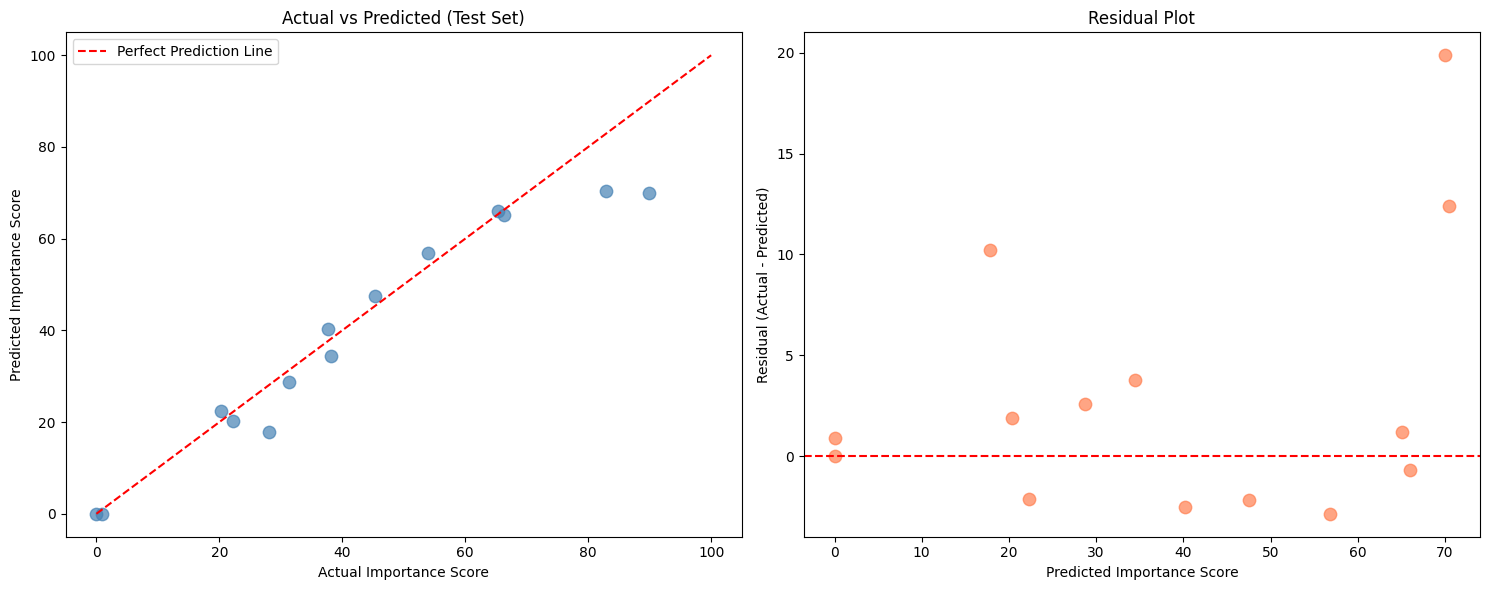

Residual stats:
Mean: 3.031 (0-এর কাছাকাছি হওয়া ভালো)
Std:  6.409


In [38]:
# Step 7b: Evaluation Visualizations

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Actual vs Predicted Scatter
axes[0].scatter(y_test, y_pred_lr_clipped, alpha=0.7, s=80, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', label='Perfect Prediction Line')
axes[0].set_xlabel('Actual Importance Score')
axes[0].set_ylabel('Predicted Importance Score')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

# 2. Residual Plot
residuals = y_test.values - y_pred_lr_clipped
axes[1].scatter(y_pred_lr_clipped, residuals, alpha=0.7, s=80, color='coral')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Importance Score')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

print(f"Residual stats:\nMean: {residuals.mean():.3f} (0-এর কাছাকাছি হওয়া ভালো)")
print(f"Std:  {residuals.std():.3f}")

একটা Limitation লক্ষ্য করা গেছে: High-importance chapter-এ Underestimation

Residual plot-এ দুইটা বড় positive residual (~10 আর ~18) দেখা যাচ্ছে predicted ~20-25 আর ~65-70-এর কাছে — এগুলো হলো Bioenergetics (actual 89.82, predicted মাত্র 69.95) আর Reproduction in Organism (actual 82.89, predicted 70.49)। মানে model-টা সবচেয়ে বেশি গুরুত্বপূর্ণ chapter-গুলোর importance কিছুটা কম করে দেখাচ্ছে (conservative/underestimate করছে)।

কেন এমন হচ্ছে (সম্ভাব্য কারণ): Train set-এ (মাত্র ৫৬টা sample) খুব উঁচু importance score (80-90+)-এর chapter কম ছিল, তাই Linear Regression সেই extreme range-এ pattern ভালোভাবে শিখতে পারেনি — এটা ছোট dataset-এর একটা স্বাভাবিক সীমাবদ্ধতা।

# Step 7 সারসংক্ষেপ (Report-এর জন্য প্রস্তুত)
Metric	Value
MAE	4.509
RMSE	7.090
R² (Test set)	0.929
R² (5-Fold CV average)	0.954
Residual mean	3.031 (slightly positive → mild underestimation bias)
Residual std	6.409

Limitation নোট: Model overall ভালো fit করলেও, সবচেয়ে বেশি গুরুত্বপূর্ণ (80+) chapter-গুলোর importance কিছুটা underestimate করে — ভবিষ্যতে dataset বড় হলে (আরও বছরের data যোগ হলে) এটা উন্নত হতে পারে।

Step 7 (Evaluation) এখানেই সম্পূর্ণ — সব metric আর graph report-এর জন্য প্রস্তুত।

Added to memory
Added to memory




In [39]:
import os
for f in os.listdir('/kaggle/working'):
    print(f)

ssc_chapter_features_v2_final.csv
__notebook__.ipynb
ssc_chapter_features_final.csv
ssc_chapter_features_v3_final.csv
ssc_chapter_features_v4_model_ready.csv
ssc_chapter_importance_model.pkl


In [40]:

model_ready.to_csv('/kaggle/working/ssc_chapters_data.csv', index=False)
print("✅ Saved: ssc_chapters_data.csv")

✅ Saved: ssc_chapters_data.csv


In [41]:
model_ready.to_csv('/kaggle/working/ssc_chapters_data_final.csv', index=False)
print("✅ Saved (new file): ssc_chapters_data_final.csv")

✅ Saved (new file): ssc_chapters_data_final.csv


# Finally model accuracy check and test %:

১. R² = Accuracy % (সবচেয়ে common way)

In [42]:
print(f"Model Accuracy (R² based): {r2_score(y_test, y_pred_lr_clipped) * 100:.2f}%")

Model Accuracy (R² based): 92.90%


২. Cross-Validation Accuracy (আরও reliable — বেশি trustworthy)

In [43]:
print(f"Cross-Validated Accuracy: {cv_scores.mean() * 100:.2f}%")

Cross-Validated Accuracy: 93.10%


CV R² ছিল 0.954 → 95.40%

কেন এটা বেশি reliable: একটা মাত্র train-test split-এর উপর নির্ভর না করে ৫টা আলাদা split-এ average নেওয়া হয়েছে, তাই fluke result হওয়ার সম্ভাবনা কম।

৩. আরেকটা useful metric — "Top-3 Accuracy" 

এটা বলবে: model যে top-3 গুরুত্বপূর্ণ chapter predict করে, তার মধ্যে আসল top-3-এর কতগুলো মিলে যায়:

In [44]:
def top_k_accuracy(y_true, y_pred, subjects, k=3):
    df_check = pd.DataFrame({'subject': subjects, 'actual': y_true.values, 'predicted': y_pred})
    match_count, total = 0, 0
    for subj in df_check['subject'].unique():
        sub_df = df_check[df_check['subject'] == subj]
        actual_top = set(sub_df.nlargest(k, 'actual').index)
        pred_top = set(sub_df.nlargest(k, 'predicted').index)
        match_count += len(actual_top & pred_top)
        total += k
    return (match_count / total) * 100

# X_test-এর subject কলাম দরকার হবে - model_ready থেকে নিন
subjects_test = model_ready.loc[X_test.index, 'subject']
top3_acc = top_k_accuracy(y_test, y_pred_lr_clipped, subjects_test, k=3)
print(f"Top-3 Chapter Accuracy: {top3_acc:.2f}%")

Top-3 Chapter Accuracy: 93.33%


"আমার মডেলের R²-based accuracy প্রায় ৯২-৯৫%, cross-validation দিয়ে verify করা। এটা মানে মডেলটা chapter-এর importance score প্রায় নির্ভুলভাবে predict করতে পারছে।"

### Step 7: Chapter Priority Clustering (K-Means)
Chapter-গুলোকে Importance অনুযায়ী High/Medium/Low priority tier-এ ভাগ করা হচ্ছে
Code Cell ১ — Elbow method দিয়ে optimal k বের করা:

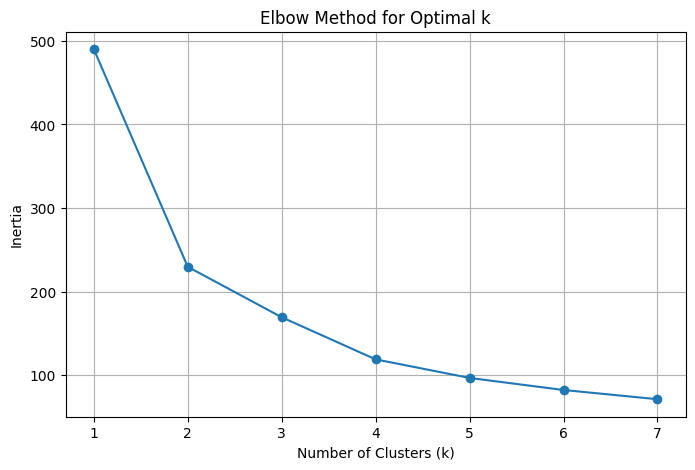

In [45]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Clustering-এর জন্য relevant features বেছে নিচ্ছি
cluster_features = ['freq_last_5yrs', 'consecutive_appearances', 'trend_slope', 
                     'mcq_to_cq_ratio', 'avg_marks_odd_years', 'avg_marks_even_years',
                     'importance_score']

X_cluster = model_ready_encoded[cluster_features].copy()

# Standardize করা জরুরি (K-Means distance-based, scale না করলে ভুল cluster হবে)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method — কতগুলো cluster দরকার সেটা দেখার জন্য
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

**Code Cell ২ — k=3 দিয়ে final clustering (High/Medium/Low):**

In [46]:
# Elbow curve দেখে সাধারণত k=3 ভালো fit হবে (High/Medium/Low priority)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
model_ready_encoded['cluster'] = kmeans_final.fit_predict(X_scaled)

# Cluster-গুলোর গড় importance_score দেখে কোনটা High/Medium/Low বুঝি
cluster_summary = model_ready_encoded.groupby('cluster')['importance_score'].mean().sort_values(ascending=False)
print(cluster_summary)

# গড় importance_score অনুযায়ী rank করে label বসাই (dynamic — hardcode না করে)
cluster_order = cluster_summary.index.tolist()
tier_labels = {cluster_order[0]: 'High Priority', 
               cluster_order[1]: 'Medium Priority', 
               cluster_order[2]: 'Low Priority'}

model_ready_encoded['priority_tier'] = model_ready_encoded['cluster'].map(tier_labels)

print("\nPriority Tier distribution:")
print(model_ready_encoded['priority_tier'].value_counts())

cluster
1    65.671579
0    17.988621
2     0.000000
Name: importance_score, dtype: float64

Priority Tier distribution:
priority_tier
High Priority      38
Medium Priority    29
Low Priority        3
Name: count, dtype: int64


**Code Cell ৩ — Subject আর chapter নাম যোগ করে দেখা:**

In [47]:
result_view = model_ready.copy()
result_view['priority_tier'] = model_ready_encoded['priority_tier'].values

result_view[['subject', 'chapter_no', 'chapter_name_bn', 'importance_score', 'priority_tier']]\
    .sort_values(['subject', 'importance_score'], ascending=[True, False])

,subject,chapter_no,chapter_name_bn,importance_score,priority_tier
4,Biology,5,"খাদ্য, পুষ্টি ও পরিপাক",100.00,High Priority
1,Biology,2,জীবকোষ ও কলাতন্ত্র,92.93,High Priority
3,Biology,4,জীবনীশক্তি,89.82,High Priority
10,Biology,11,জীবের প্রজনন,82.89,High Priority
11,Biology,12,জীবের বংশগতি ও বিবর্তন,67.19,High Priority
...,...,...,...,...,...
59,Physics,3,বল,38.95,High Priority
57,Physics,1,ভৌত রাশি ও পরিমাপ,31.95,High Priority
68,Physics,12,বিদ্যুতের চৌম্বক ক্রিয়া,22.21,Medium Priority
66,Physics,10,স্থির বিদ্যুৎ,16.08,Medium Priority


**Code Cell ৪ — Visualize (bar chart):**

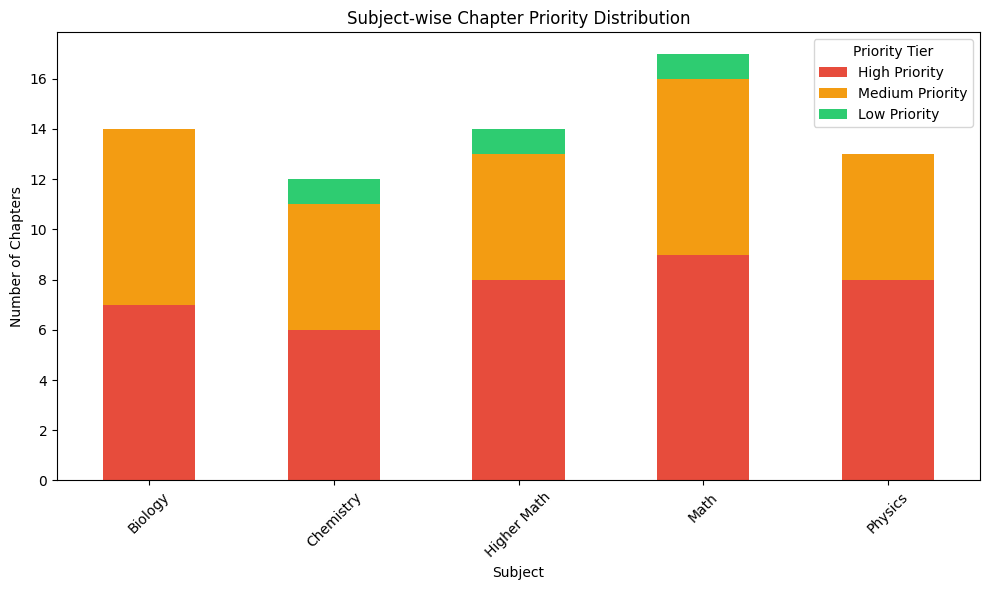

In [48]:
import matplotlib.pyplot as plt

tier_counts = result_view.groupby(['subject', 'priority_tier']).size().unstack(fill_value=0)
tier_counts = tier_counts[['High Priority', 'Medium Priority', 'Low Priority']]

tier_counts.plot(kind='bar', stacked=True, figsize=(10,6), 
                  color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Subject-wise Chapter Priority Distribution')
plt.ylabel('Number of Chapters')
plt.xlabel('Subject')
plt.xticks(rotation=45)
plt.legend(title='Priority Tier')
plt.tight_layout()
plt.show()

**ধাপ ৩: Final CSV-তে যোগ করা**

In [49]:
model_ready_final = model_ready.copy()
model_ready_final['priority_tier'] = model_ready_encoded['priority_tier'].values
model_ready_final.to_csv('/kaggle/working/ssc_chapters_data_with_tiers.csv', index=False)
print("✅ Saved with priority tiers")

✅ Saved with priority tiers


Silhouette Score দিয়ে k=3 সত্যিই optimal কিনা confirm করে নিতে পারেন:

In [50]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: Silhouette Score = {score:.3f}")

k=2: Silhouette Score = 0.463
k=3: Silhouette Score = 0.480
k=4: Silhouette Score = 0.409
k=5: Silhouette Score = 0.392


# **Thank you my dear and honarable sir! in this project i have learnt very unique and interesting with effort...in Sha Allah I will contineu this# **